## Kernel Ridge Regression — Credit Scoring Bancaire
### Dataset : Give Me Some Credit (Kaggle — GiveMeSomeCredit)
### Objectif : Prédire le revenu mensuel d'un client depuis son comportement financier

In [8]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\afagn\.cache\kagglehub\datasets\brycecf\give-me-some-credit-dataset\versions\1


In [10]:
# CHARGEMENT ET PREPARATION DES DONNEES

import os
df = pd.read_csv(os.path.join(path, "cs-training.csv"), index_col=0)

print(f"\n[Dataset brut]")
print(f"  Samples        : {len(df)}")
print(f"  Features       : {df.shape[1]}")
print(f"  Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")



# Nettoyage
df = df.dropna(subset=['MonthlyIncome'])          # supprimer lignes sans revenu
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

q99 = df['MonthlyIncome'].quantile(0.99)
df  = df[df['MonthlyIncome'] <= q99]
df  = df[df['MonthlyIncome'] > 0]

print(f"\n[Dataset nettoyé]")
print(f"  Samples retenus : {len(df)}")
print(f"  MonthlyIncome   : min={df['MonthlyIncome'].min():.0f}  "
      f"max={df['MonthlyIncome'].max():.0f}  "
      f"moyenne={df['MonthlyIncome'].mean():.0f}")

# Features : comportement financier du client
features = [
    'RevolvingUtilizationOfUnsecuredLines',  # utilisation des lignes de crédit
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',  # retards 30-59 jours
    'DebtRatio',                             # ratio d'endettement
    'NumberOfOpenCreditLinesAndLoans',       # nombre de crédits ouverts
    'NumberOfTimes90DaysLate',              # retards graves
    'NumberRealEstateLoansOrLines',          # crédits immobiliers
    'NumberOfTime60-89DaysPastDueNotWorse',  # retards 60-89 jours
    'NumberOfDependents'                     # personnes à charge
]


[Dataset brut]
  Samples        : 150000
  Features       : 11
  Valeurs manquantes :
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

[Dataset nettoyé]
  Samples retenus : 117467
  MonthlyIncome   : min=1  max=25000  moyenne=6252


In [11]:


X = df[features].values
y = df['MonthlyIncome'].values

# Sous-échantillonnage pour KRR (O(n²) — lent sur 100k+)
np.random.seed(42)
idx = np.random.choice(len(X), size=5000, replace=False)
X, y = X[idx], y[idx]

# Split principal : 80% train, 20% test final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Split validation depuis le train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sc, y_train, test_size=0.2, random_state=42
)

print(f"\n[Split]")
print(f"  Train      : {X_tr.shape[0]}")
print(f"  Validation : {X_val.shape[0]}")
print(f"  Test final : {X_test_sc.shape[0]}")


[Split]
  Train      : 3200
  Validation : 800
  Test final : 1000


In [12]:
# ENTRAINEMENT DU MODELE KERNEL RIDGE REGRESSION

# alpha : régularisation — évite l'overfitting
# kernel rbf : capture les relations non linéaires entre comportement financier et revenu
# gamma : contrôle la portée de l'influence de chaque point d'entraînement
krr = KernelRidge(alpha=0.1, kernel='rbf', gamma=0.01)
krr.fit(X_tr, y_tr)

# Prédictions
y_pred_val  = krr.predict(X_val)
y_pred_test = krr.predict(X_test_sc)

In [13]:
# METRIQUES VALIDATION + TEST FINAL

r2_val   = r2_score(y_val,  y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val  = mean_absolute_error(y_val, y_pred_val)

r2_test   = r2_score(y_test,  y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)

residuals = y_test - y_pred_test

print("\n[Validation]")
print(f"  R²   : {r2_val:.4f}")
print(f"  RMSE : {rmse_val:.2f} USD/mois")
print(f"  MAE  : {mae_val:.2f} USD/mois")

print("\n[Test Final]")
print(f"  R²   : {r2_test:.4f}")
print(f"  RMSE : {rmse_test:.2f} USD/mois")
print(f"  MAE  : {mae_test:.2f} USD/mois")

print(f"\n[Résidus]")
print(f"  Moyenne : {residuals.mean():.2f}")
print(f"  Std     : {residuals.std():.2f}")
print(f"  Min     : {residuals.min():.2f}")
print(f"  Max     : {residuals.max():.2f}")


[Validation]
  R²   : 0.2453
  RMSE : 3398.67 USD/mois
  MAE  : 2524.80 USD/mois

[Test Final]
  R²   : 0.2028
  RMSE : 3618.24 USD/mois
  MAE  : 2628.34 USD/mois

[Résidus]
  Moyenne : 122.89
  Std     : 3616.15
  Min     : -7611.23
  Max     : 17006.87


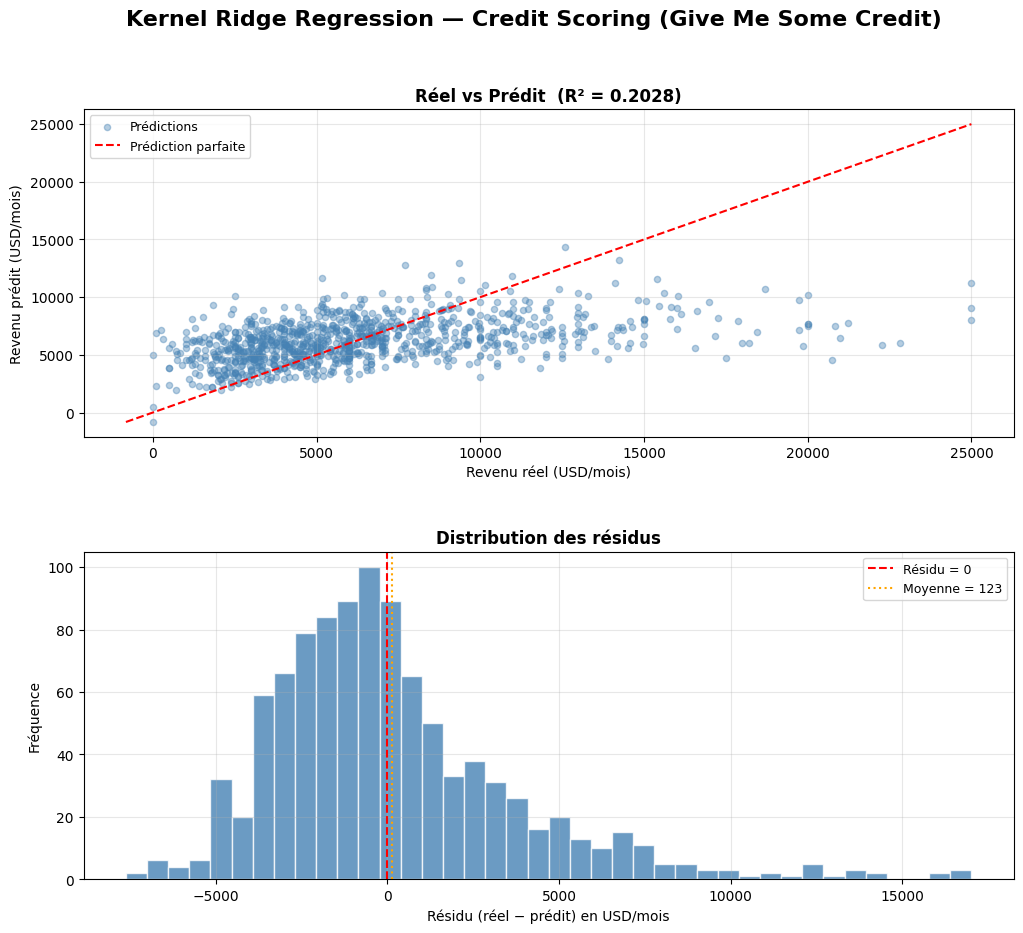

In [ ]:
# VISUALISATIONS

fig = plt.figure(figsize=(12, 10))
fig.suptitle("Kernel Ridge Regression — Credit Scoring (Give Me Some Credit)",
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)

# 1) Valeurs réelles vs prédictions
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred_test, alpha=0.4, color='steelblue', s=20, label='Prédictions')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
ax1.set_xlabel('Revenu réel (USD/mois)')
ax1.set_ylabel('Revenu prédit (USD/mois)')
ax1.set_title(f'Réel vs Prédit  (R² = {r2_test:.4f})', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2) Distribution des résidus
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', lw=1.5, label='Résidu = 0')
ax2.axvline(residuals.mean(), color='orange', linestyle=':', lw=1.5,
            label=f'Moyenne = {residuals.mean():.0f}')
ax2.set_xlabel('Résidu (réel − prédit) en USD/mois')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution des résidus', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.show()